In [1]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score

sys.path.append(str(Path().resolve().parent))

from src.data import get_data
from src.features import generate_features
from src.backtest import backtest, results_table, optimize, optimize_assets, fit_strategy, sharpe_ratio, optimize_tt
from src.strategy import (
    logistic_strategy, 
    momentum_strategy, 
    momentum_volatility_strategy, 
    mean_reversion_strategy, 
    momentum_trend_strategy, 
    momentum_voluratio_strategy,
    randforest_strategy
)
from src.visualization import plot_performance
from src.ml import build_ml_dataset, train_logistic, train_randforest
from src.finance import calculate_beta
from src.portfolio import optimize_portfolio, create_portfolio_df, efficient_frontier

In [40]:
assets = ['AAPL', 'MSFT','SPY', 'NVDA','TTD','DOCS','IBM','BE','XOM','GLD','JNJ','SCCO','ECL','JPM','META', 'QQQ']
assets = ['AAPL', 'MSFT', 'NVDA','TTD','DOCS','IBM','BE','XOM','GLD','JNJ','SCCO','ECL','JPM','META']

returns_df = pd.DataFrame()

for asset in assets:
    df = get_data(asset, "2016-01-01", "2026-01-01")
    df = generate_features(df)
    returns_df[asset] = df["returns"]

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [41]:
returns_df.head()

,AAPL,MSFT,NVDA,TTD,DOCS,IBM,BE,XOM,GLD,JNJ,SCCO,ECL,JPM,META
2016-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-01-05,-0.025059,0.004562,0.016064,NaN,NaN,-0.000736,NaN,0.008521,0.002819,0.004180,0.011302,0.003645,0.001729,0.004989
2016-01-06,-0.019570,-0.018165,-0.041350,NaN,NaN,-0.005006,NaN,-0.008321,0.014441,-0.005055,-0.028902,-0.042781,-0.014436,0.002336
2016-01-07,-0.042205,-0.034783,-0.039645,NaN,NaN,-0.017090,NaN,-0.016006,0.014140,-0.011655,-0.025397,-0.025909,-0.040439,-0.049043
2016-01-08,0.005288,0.003067,-0.021466,NaN,NaN,-0.009258,NaN,-0.020202,-0.004428,-0.010683,-0.019951,-0.008739,-0.022399,-0.006025


## Correlation Analysis

In [42]:
corr_matrix = returns_df.corr()


In [ ]:
#corr_matrix.to_csv("../outputs/correlation_matrix.csv")


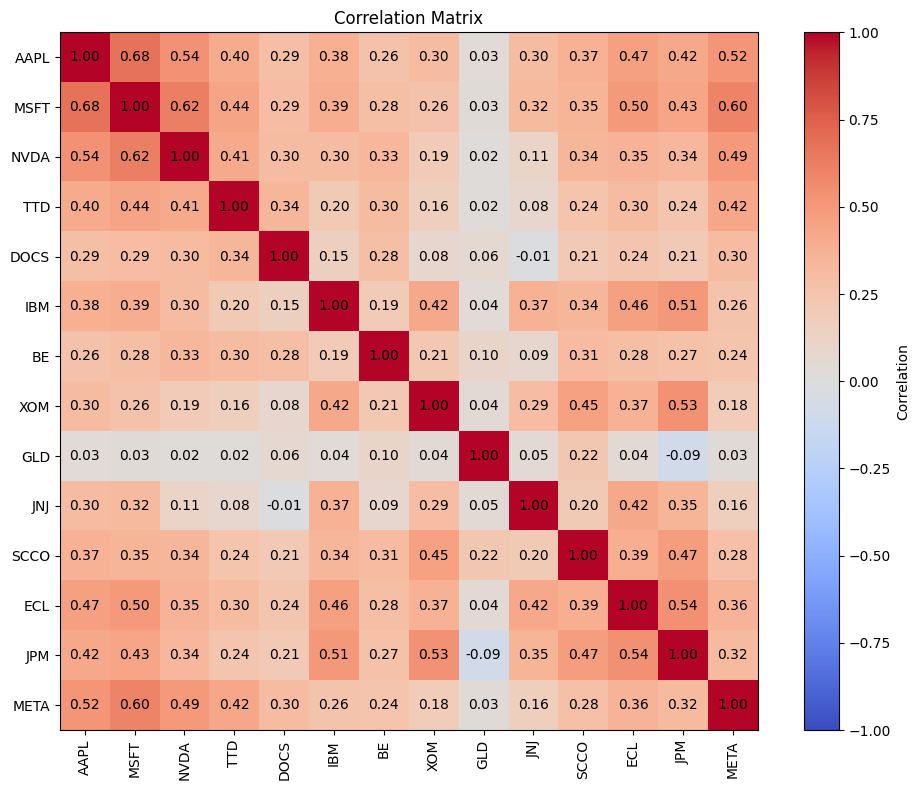

In [43]:
plt.figure(figsize=(10, 8))

plt.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)

plt.colorbar(label="Correlation")

plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)

for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix.columns)):
        plt.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}",
                 ha="center", va="center", color="black")

plt.title("Correlation Matrix")
plt.tight_layout()

plt.show()

## Covariance Maatrix

In [7]:
cov_matrix = returns_df.cov()
cov_matrix

,AAPL,MSFT,SPY,NVDA,TTD,DOCS,IBM,BE,XOM,GLD,JNJ,SCCO,ECL,JPM,META,QQQ
AAPL,0.000335,0.000209,0.000157,0.000309,0.000320,0.000220,0.000110,0.000304,0.000097,0.000006,0.000064,0.000154,0.000136,0.000133,0.000232,0.000208
MSFT,0.000209,0.000284,0.000153,0.000328,0.000325,0.000209,0.000104,0.000302,0.000078,0.000004,0.000062,0.000133,0.000133,0.000128,0.000246,0.000204
SPY,0.000157,0.000153,0.000130,0.000233,0.000236,0.000180,0.000106,0.000286,0.000105,0.000005,0.000060,0.000143,0.000125,0.000141,0.000169,0.000149
NVDA,0.000309,0.000328,0.000233,0.000988,0.000573,0.000443,0.000149,0.000641,0.000105,0.000006,0.000041,0.000243,0.000175,0.000184,0.000375,0.000331
TTD,0.000320,0.000325,0.000236,0.000573,0.001873,0.000636,0.000138,0.000785,0.000123,0.000009,0.000041,0.000242,0.000209,0.000181,0.000451,0.000327
DOCS,0.000220,0.000209,0.000180,0.000443,0.000636,0.001911,0.000099,0.000649,0.000058,0.000025,-0.000005,0.000214,0.000157,0.000141,0.000370,0.000251
IBM,0.000110,0.000104,0.000106,0.000149,0.000138,0.000099,0.000246,0.000192,0.000116,0.000005,0.000067,0.000122,0.000115,0.000138,0.000097,0.000107
BE,0.000304,0.000302,0.000286,0.000641,0.000785,0.000649,0.000192,0.003505,0.000245,0.000059,0.000062,0.000440,0.000292,0.000297,0.000382,0.000349
XOM,0.000097,0.000078,0.000105,0.000105,0.000123,0.000058,0.000116,0.000245,0.000311,0.000007,0.000059,0.000182,0.000104,0.000164,0.000077,0.000086
GLD,0.000006,0.000004,0.000005,0.000006,0.000009,0.000025,0.000005,0.000059,0.000007,0.000087,0.000005,0.000047,0.000006,-0.000015,0.000006,0.000008


In [8]:
cov_matrix.to_csv("../outputs/covariance_matrix.csv")

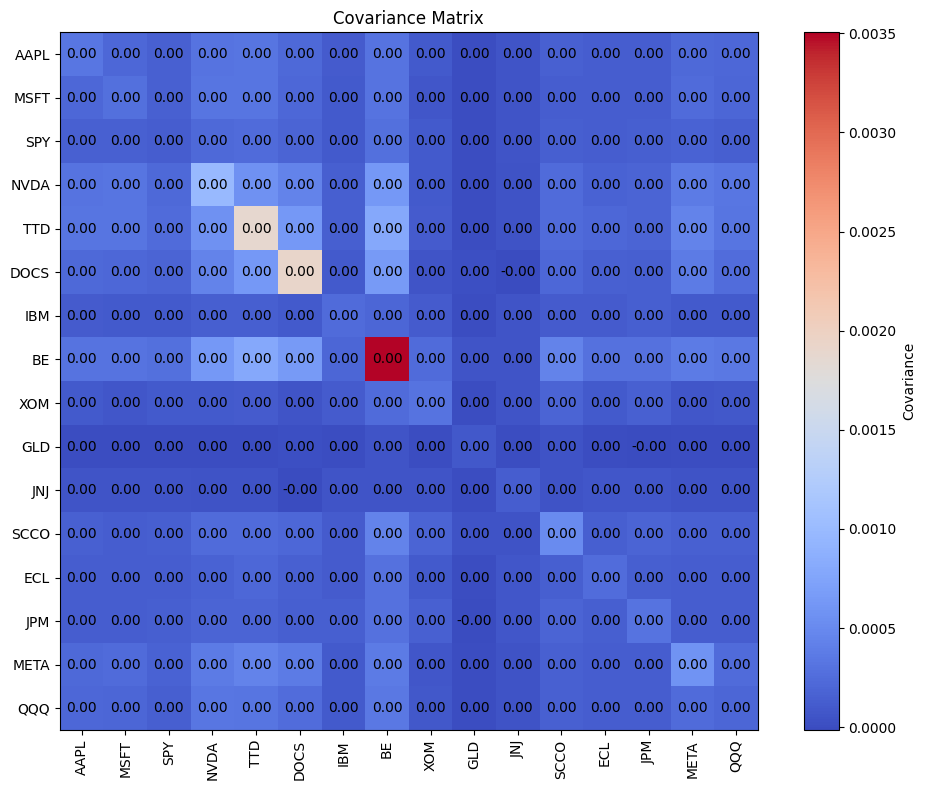

In [9]:
plt.figure(figsize=(10, 8))

plt.imshow(cov_matrix, cmap="coolwarm")

plt.colorbar(label="Covariance")

plt.xticks(range(len(cov_matrix.columns)), cov_matrix.columns, rotation=90)
plt.yticks(range(len(cov_matrix.index)), cov_matrix.index)

for i in range(len(cov_matrix)):
    for j in range(len(cov_matrix.columns)):
        plt.text(j, i, f"{cov_matrix.iloc[i, j]:.2f}",
                 ha="center", va="center", color="black")

plt.title("Covariance Matrix")
plt.tight_layout()

plt.show()

## Portfolio Building

In [10]:
weights_A = {'AAPL': 0.25, 'MSFT': 0.25, 'NVDA': 0.25,'IBM': 0.25}

weights_B = {'AAPL': 0.25,'NVDA': 0.25,'GLD': 0.25,'JNJ': 0.25}

weights_C = {'SPY': 1/3, 'QQQ': 1/3, 'GLD': 1/3}

In [11]:
portfolio_returns_A = (returns_df[list(weights_A.keys())] * list(weights_A.values())).sum(axis=1)
portfolio_return_A = portfolio_returns_A.mean() * 252
portfolio_volatility_A = (portfolio_returns_A.std() * np.sqrt(252))
portfolio_sharpe_A = sharpe_ratio(portfolio_returns_A)
portfolio_cumulative_A = (1 + portfolio_returns_A).cumprod()


portfolio_returns_B = (returns_df[list(weights_B.keys())] * list(weights_B.values())).sum(axis=1)
portfolio_return_B = portfolio_returns_B.mean() * 252
portfolio_volatility_B = (portfolio_returns_B.std() * np.sqrt(252))
portfolio_sharpe_B = sharpe_ratio(portfolio_returns_B)
portfolio_cumulative_B = (1 + portfolio_returns_B).cumprod()

portfolio_returns_C = (returns_df[list(weights_C.keys())] * list(weights_C.values())).sum(axis=1)
portfolio_return_C = portfolio_returns_C.mean() * 252
portfolio_volatility_C = (portfolio_returns_C.std() * np.sqrt(252))
portfolio_sharpe_C = sharpe_ratio(portfolio_returns_C)
portfolio_cumulative_C = (1 + portfolio_returns_C).cumprod()

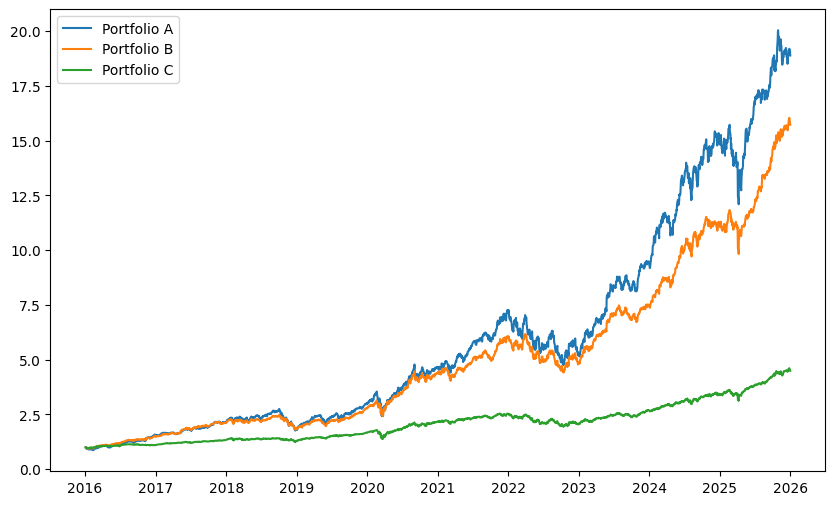

In [12]:
plt.figure(figsize=(10,6))

plt.plot(portfolio_cumulative_A, label="Portfolio A")
plt.plot(portfolio_cumulative_B, label="Portfolio B")
plt.plot(portfolio_cumulative_C, label="Portfolio C")


plt.legend()
plt.show()

In [13]:
summary_table = pd.DataFrame({
    'Annual Return': {
        'Portfolio A': portfolio_return_A,
        'Portfolio B': portfolio_return_B,
        'Portfolio C': portfolio_return_C
    },
    'Annual Volatility': {
        'Portfolio A': portfolio_volatility_A,
        'Portfolio B': portfolio_volatility_B,
        'Portfolio C': portfolio_volatility_C
    },
    'Sharpe Ratio': {
        'Portfolio A': portfolio_sharpe_A,
        'Portfolio B': portfolio_sharpe_B,
        'Portfolio C': portfolio_sharpe_C
    }
})

summary_table

,Annual Return,Annual Volatility,Sharpe Ratio
Portfolio A,0.328311,0.259243,1.266418
Portfolio B,0.295243,0.194642,1.516850
Portfolio C,0.160977,0.143947,1.118311


## Applied Strategies

In [47]:
df = pd.read_csv("../outputs/experiment_results.csv")
assets = ['AAPL', 'META', 'SPY']

filtered_df = df[df['Asset'].isin(assets)]

result = (
    filtered_df
    .groupby('Strategy', as_index=False)
    .mean(numeric_only=True)
)
result

,Strategy,Window,Threshold,Train Sharpe,Train Volatility,Train Max DD,Train Signal Accuracy,Train Signal Precision,Train Signal Recall,Train Signal Active %,Test Sharpe,Test Volatility,Test Max DD,Test Signal Accuracy,Test Signal Precision,Test Signal Recall,Test Signal Active %
0,Logistic Regression,NaN,NaN,0.735991,0.262498,-0.424230,0.537521,0.539997,0.884042,87.199166,1.376909,0.159337,-0.182493,0.515673,0.558276,0.578086,57.262693
1,Mean Reversion,7.333333,2.666667,0.856230,0.141850,-0.138785,0.485124,0.598858,0.116875,10.574190,-0.171891,0.109225,-0.156879,0.451656,0.337762,0.084162,8.830022
2,Momentum,24.666667,NaN,0.952056,0.177400,-0.239886,0.521129,0.541232,0.643357,63.179837,1.260561,0.189021,-0.168306,0.523179,0.555013,0.683033,67.814570
3,Momentum + Rolling Volatility,24.666667,4.000000,1.074730,0.161413,-0.167273,0.519803,0.543895,0.598256,58.537048,1.175405,0.183900,-0.168581,0.516556,0.551342,0.652203,65.121413
4,Momentum + Trend Strength,7.333333,NaN,0.808182,0.133846,-0.158827,0.500853,0.536979,0.419069,41.444002,0.898803,0.145877,-0.175190,0.488300,0.541761,0.447027,45.430464
5,Momentum + Volume Ratio,24.666667,NaN,0.578348,0.117990,-0.179223,0.486072,0.538942,0.218957,21.546333,0.964020,0.127481,-0.128350,0.475055,0.549544,0.244099,24.415011
6,Random Forest,NaN,NaN,8.924576,0.173970,0.000000,0.984650,1.000000,0.971120,51.620239,1.376034,0.172020,-0.181446,0.511700,0.581006,0.448942,43.267108


In [48]:
portfolio_A = create_portfolio_df(
    weights_A,
    "2016-01-01",
    "2026-01-01"
)

portfolio_A = generate_features(portfolio_A)

split_idx = int(len(portfolio_A) * 0.7)

train_A = portfolio_A.iloc[:split_idx].copy()
test_A = portfolio_A.iloc[split_idx:].copy()

train_results_A, test_results_A = optimize_tt(
    train=train_A,
    test=test_A,
    strategies=strategies,
    windows=range(2, 50, 2),
    feature_set="v1",
    asset="Portfolio B",
    save_csv=False,
    windowplot=False,
    performanceplot=False,
    logscale=True
)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Momentum
Market Sharpe Ratio: 0.9428
Best Momentum Strategy window: 12
Best Sharpe ratio: 1.1210

Momentum + Rolling Volatility
Market Sharpe Ratio: 0.9428
Best Momentum + Rolling Volatility Strategy window: 10
Best threshold: 2%
Best Sharpe ratio: 1.4070

Logistic Regression
Training ML model...
Logistic Regression model trained and tested.

Random Forest
Training ML model...
Random Forest model trained and tested.



In [17]:
results_table(train_A)

,Strategy,Sharpe,Volatility,Max DD,Signal Accuracy,Signal Precision,Signal Recall,Signal Active %
0,Market,0.942777,0.366140,-0.554597,NaN,NaN,NaN,NaN
1,Momentum,1.120952,0.246098,-0.307626,0.519613,0.552305,0.646937,64.127345
2,Momentum + Rolling Volatility,1.406966,0.152957,-0.185768,0.508812,0.568088,0.428868,41.330301
3,Logistic Regression,0.945540,0.363467,-0.554597,0.546902,0.548538,0.974039,97.214326
4,Random Forest,9.605254,0.225205,0.000000,0.985787,1.000000,0.974039,53.325753


In [18]:
results_table(test_A)

,Strategy,Sharpe,Volatility,Max DD,Signal Accuracy,Signal Precision,Signal Recall,Signal Active %
0,Market,1.887988,0.440806,-0.351228,NaN,NaN,NaN,NaN
1,Momentum,1.455025,0.321772,-0.407365,0.504636,0.545082,0.636364,64.635762
2,Momentum + Rolling Volatility,1.257103,0.181859,-0.143166,0.460927,0.528497,0.244019,25.562914
3,Logistic Regression,1.898291,0.441016,-0.351228,0.553642,0.553642,1.000000,100.000000
4,Random Forest,1.103660,0.264563,-0.323996,0.496689,0.551913,0.483254,48.476821


## Efficient Frontier

In [19]:
assets_A = ['AAPL', 'MSFT', 'NVDA', 'IBM']
assets_B = ['AAPL', 'NVDA', 'GLD', 'JNJ']
assets_C = ['SPY', 'QQQ', 'GLD']

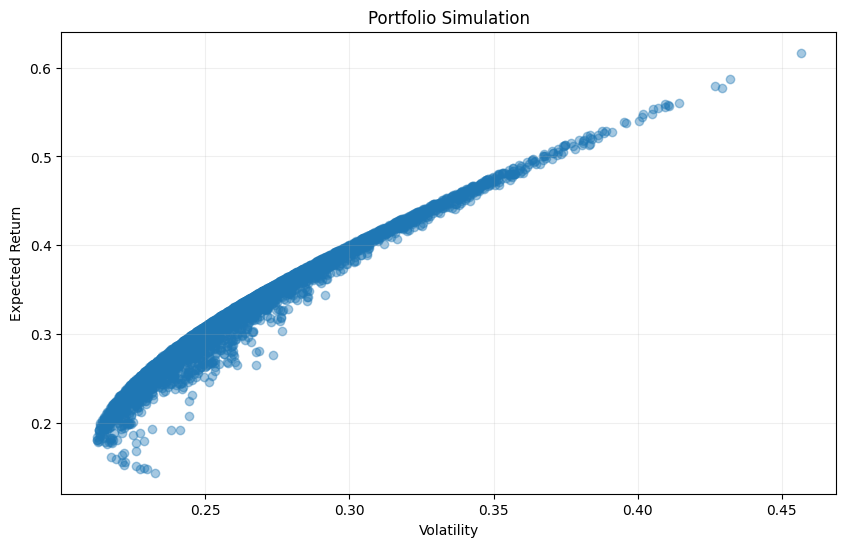

(array([0.32174772, 0.31944101, 0.29827567, ..., 0.32946058, 0.29364076,
        0.2185684 ], shape=(5000,)),
 array([0.25591489, 0.26673605, 0.24488122, ..., 0.26027402, 0.24741833,
        0.21747725], shape=(5000,)))

In [31]:
efficient_frontier(assets = assets_A, returns_df = returns_df)

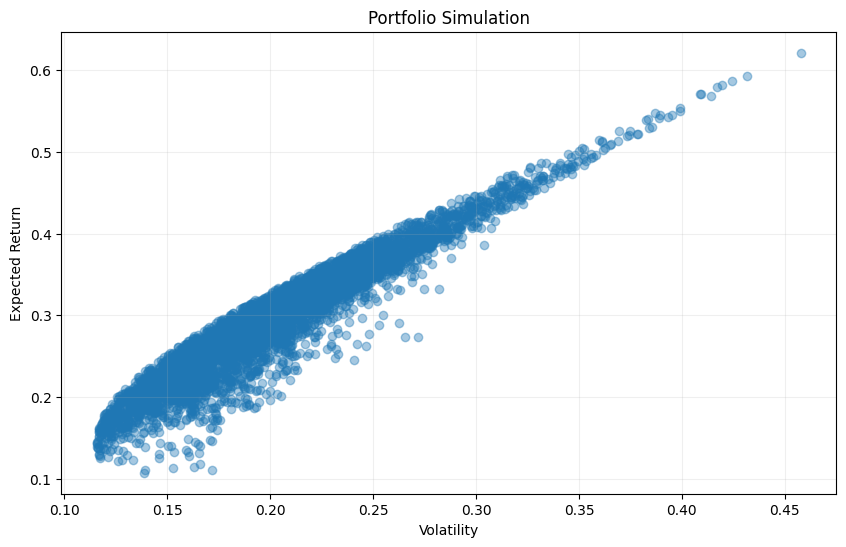

(array([0.35307152, 0.32180718, 0.33912042, ..., 0.25336604, 0.15233303,
        0.40831762], shape=(5000,)),
 array([0.2369401 , 0.24595593, 0.24180997, ..., 0.15139464, 0.12263043,
        0.27251817], shape=(5000,)))

In [29]:
efficient_frontier(assets = assets_B, returns_df = returns_df)

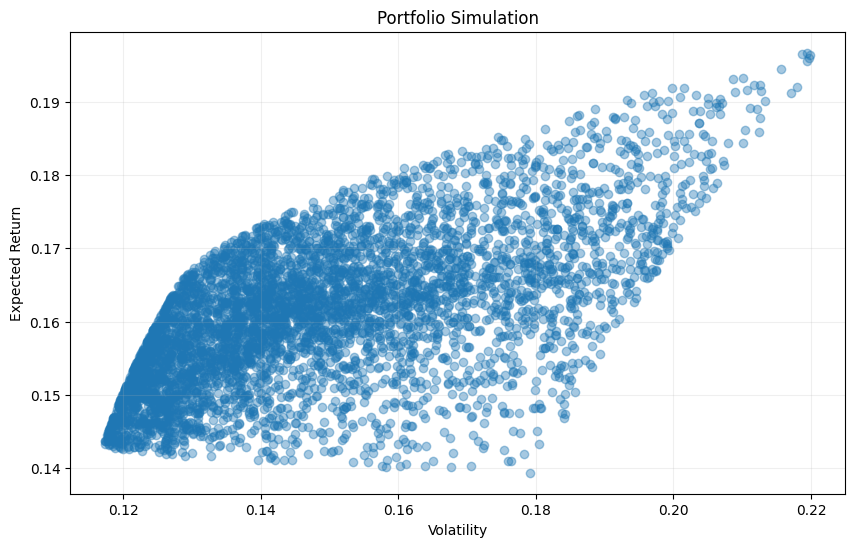

(array([0.17237036, 0.17719669, 0.1622245 , ..., 0.16571685, 0.16785772,
        0.16698775], shape=(5000,)),
 array([0.19058521, 0.17994738, 0.13132221, ..., 0.13767337, 0.17979574,
        0.18132087], shape=(5000,)))

In [26]:
efficient_frontier(assets = assets_C, returns_df = returns_df)